In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Learning Curves

Text(0, 0.5, 'y')

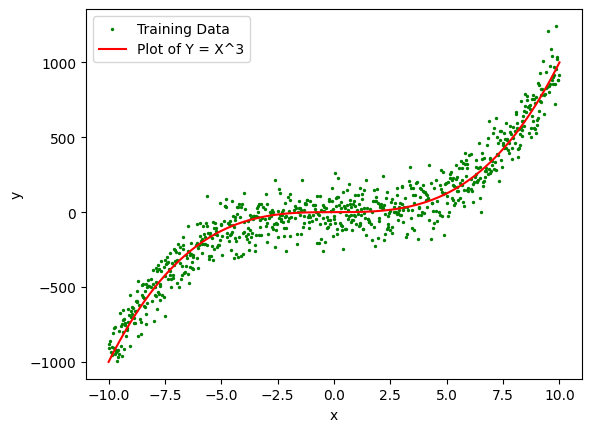

In [25]:
X = np.linspace(-10, 10, 1000)
y = X**3

#Splitting data into training and validation sets
X_train, X_val, y_train_true, y_val = train_test_split(X, y, test_size = 0.2)
noise = np.random.normal(0, 100, int(1000*(1 - 0.2)))

y_train = y_train_true + noise
X_train = X_train.reshape(-1, 1)
X_val = X_val.reshape(-1, 1)

plt.scatter(X_train, y_train, color = 'Green', s = 2, label = 'Training Data')
plt.plot(X, y, color = 'red', label = 'Plot of Y = X^3')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')

In [50]:
sorted_idx = np.argsort(X_val.flatten())
sorted_X_val = X_val.flatten()[sorted_idx]
sorted_y_val = y_val[sorted_idx]

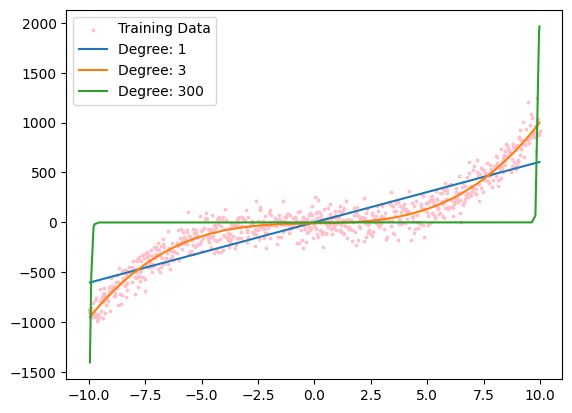

In [55]:
#I'm going to train a degree 1, degree 3, and degree 300 regression on the dataset to determine the error
poly3 = PolynomialFeatures(degree = 3, include_bias = False)
X_train3 = poly3.fit_transform(X_train)
X_val3 = poly3.fit_transform(X_val)

poly300 = PolynomialFeatures(degree = 300, include_bias = False)
X_train300 = poly300.fit_transform(X_train)
X_val300 = poly300.fit_transform(X_val)

training_X = [X_train, X_train3, X_train300]
val_X = [X_val, X_val3, X_val300]

lin_reg = LinearRegression()
plt.scatter(X_train, y_train, color = 'pink', label = 'Training Data', s = 3)

for i in range(len(training_X)):
    lin_reg.fit(training_X[i], y_train)

    y_pred = lin_reg.predict(val_X[i])
    sorted_y_pred = y_pred[sorted_idx]
    plt.plot(sorted_X_val, sorted_y_pred, label = f'Degree: {training_X[i].shape[1]}')

plt.legend()


In [59]:
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

    train_errors, val_errors = [], []

    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])

        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val[:m])

        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val[:m], y_val_predict))

    plt.plot(np.sqrt(train_errors), 'r-+', linewidth = 2, label = 'train')
    plt.plot(np.sqrt(val_errors), 'b-', linewidth = 2, label = 'val')
    plt.xlabel('Training set size')
    plt.ylabel('RMSE')
    plt.legend()

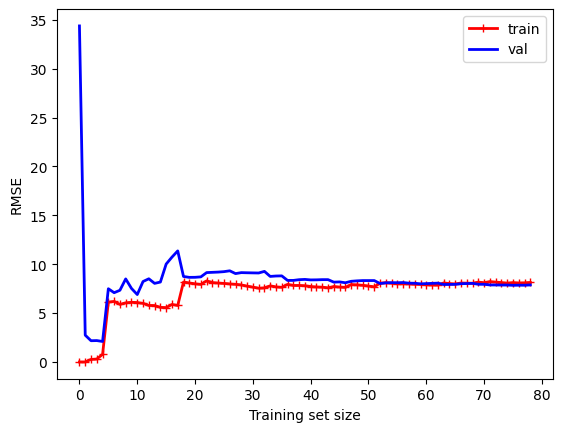

In [62]:
lin_reg_learning = LinearRegression()

plot_learning_curves(lin_reg_learning, X[:100].reshape(-1, 1), y[:100])

In [65]:
from sklearn.pipeline import Pipeline

poly3_learning = Pipeline([
    ('poly_features', PolynomialFeatures(degree = 3, include_bias = False)),
    ('lin_reg', LinearRegression())
])

poly300_learning = Pipeline([
    ('poly_features', PolynomialFeatures(degree = 300, include_bias = False)),
    ('lin_reg', LinearRegression())
])



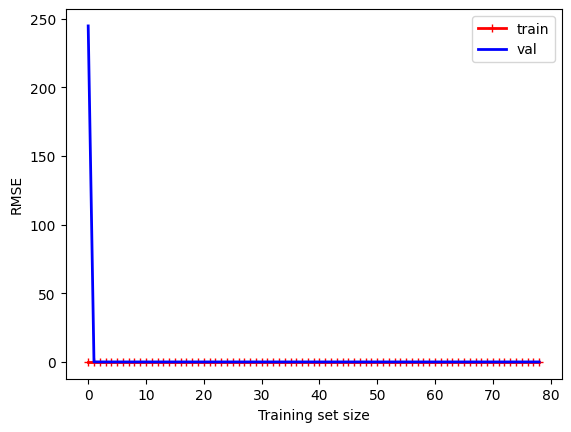

In [67]:
plot_learning_curves(poly3_learning, X[:100].reshape(-1, 1), y[:100])

In [ ]:

plot_learning_curves(poly300_learning, X[:100].reshape(-1, 1), y[:100])

TypeError: 'Pipeline' object is not callable